In [75]:
import pandas as pd
import numpy as np
dataset = pd.read_csv("/Users/roslyn/Documents/Undergrad/AZAM_Project/Naive_Bayes_CC/data/risk_factors_cervical_cancer.csv")

In [76]:
#loads the regular expressions module for strings

import re


In [77]:
#shows first few rows and columns of datset with column headings

dataset.head()

,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,...,STDs: Time since first diagnosis,STDs: Time since last diagnosis,Dx:Cancer,Dx:CIN,Dx:HPV,Dx,Hinselmann,Schiller,Citology,Biopsy
0,18,4.0,15.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,?,?,0,0,0,0,0,0,0,0
1,15,1.0,14.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,?,?,0,0,0,0,0,0,0,0
2,34,1.0,?,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,?,?,0,0,0,0,0,0,0,0
3,52,5.0,16.0,4.0,1.0,37.0,37.0,1.0,3.0,0.0,...,?,?,1,0,1,0,0,0,0,0
4,46,3.0,21.0,4.0,0.0,0.0,0.0,1.0,15.0,0.0,...,?,?,0,0,0,0,0,0,0,0


**CLEANING DATASET**

In [78]:
#clean dataset: 

dataset.columns = (
    dataset.columns.str.strip() #remove trailing and following whitespaces
              .str.lower() #changes column title names to lowercase
              .str.replace(' ', '_') #replace whitespace with underscore
              .str.replace(':', '_') #replace colon with underscore
              .str.replace(r'[()]', '', regex=True) #removes parenthesis 
)

In [79]:
#shows number of rows and columns and some missing values

dataset.info

<bound method DataFrame.info of      age number_of_sexual_partners first_sexual_intercourse  \
0     18                       4.0                     15.0   
1     15                       1.0                     14.0   
2     34                       1.0                        ?   
3     52                       5.0                     16.0   
4     46                       3.0                     21.0   
..   ...                       ...                      ...   
853   34                       3.0                     18.0   
854   32                       2.0                     19.0   
855   25                       2.0                     17.0   
856   33                       2.0                     24.0   
857   29                       2.0                     20.0   

    num_of_pregnancies smokes smokes_years smokes_packs/year  \
0                  1.0    0.0          0.0               0.0   
1                  1.0    0.0          0.0               0.0   
2                  

In [80]:
#number of observations (rows) and features (columns)
dataset.shape

(858, 36)

In [81]:
# get the number of missing data points per column
missing_values_count = dataset.isnull().sum()
print(missing_values_count)

age                                   0
number_of_sexual_partners             0
first_sexual_intercourse              0
num_of_pregnancies                    0
smokes                                0
smokes_years                          0
smokes_packs/year                     0
hormonal_contraceptives               0
hormonal_contraceptives_years         0
iud                                   0
iud_years                             0
stds                                  0
stds_number                           0
stds_condylomatosis                   0
stds_cervical_condylomatosis          0
stds_vaginal_condylomatosis           0
stds_vulvo-perineal_condylomatosis    0
stds_syphilis                         0
stds_pelvic_inflammatory_disease      0
stds_genital_herpes                   0
stds_molluscum_contagiosum            0
stds_aids                             0
stds_hiv                              0
stds_hepatitis_b                      0
stds_hpv                              0


In [82]:
# find categorical variables

categorical = [var for var in dataset.columns if dataset[var].dtype=='O']

print('There are {} categorical variables\n'.format(len(categorical)))

print('The categorical variables are :\n\n', categorical)

There are 26 categorical variables

The categorical variables are :

 ['number_of_sexual_partners', 'first_sexual_intercourse', 'num_of_pregnancies', 'smokes', 'smokes_years', 'smokes_packs/year', 'hormonal_contraceptives', 'hormonal_contraceptives_years', 'iud', 'iud_years', 'stds', 'stds_number', 'stds_condylomatosis', 'stds_cervical_condylomatosis', 'stds_vaginal_condylomatosis', 'stds_vulvo-perineal_condylomatosis', 'stds_syphilis', 'stds_pelvic_inflammatory_disease', 'stds_genital_herpes', 'stds_molluscum_contagiosum', 'stds_aids', 'stds_hiv', 'stds_hepatitis_b', 'stds_hpv', 'stds__time_since_first_diagnosis', 'stds__time_since_last_diagnosis']


In [83]:
categorical = dataset.select_dtypes(include='object').columns

In [84]:
# view the categorical variables

dataset[categorical].head()

,number_of_sexual_partners,first_sexual_intercourse,num_of_pregnancies,smokes,smokes_years,smokes_packs/year,hormonal_contraceptives,hormonal_contraceptives_years,iud,iud_years,...,stds_syphilis,stds_pelvic_inflammatory_disease,stds_genital_herpes,stds_molluscum_contagiosum,stds_aids,stds_hiv,stds_hepatitis_b,stds_hpv,stds__time_since_first_diagnosis,stds__time_since_last_diagnosis
0,4.0,15.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,?,?
1,1.0,14.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,?,?
2,1.0,?,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,?,?
3,5.0,16.0,4.0,1.0,37.0,37.0,1.0,3.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,?,?
4,3.0,21.0,4.0,0.0,0.0,0.0,1.0,15.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,?,?


In [85]:
# check missing values in categorical variables

dataset[categorical].isnull().sum()

number_of_sexual_partners             0
first_sexual_intercourse              0
num_of_pregnancies                    0
smokes                                0
smokes_years                          0
smokes_packs/year                     0
hormonal_contraceptives               0
hormonal_contraceptives_years         0
iud                                   0
iud_years                             0
stds                                  0
stds_number                           0
stds_condylomatosis                   0
stds_cervical_condylomatosis          0
stds_vaginal_condylomatosis           0
stds_vulvo-perineal_condylomatosis    0
stds_syphilis                         0
stds_pelvic_inflammatory_disease      0
stds_genital_herpes                   0
stds_molluscum_contagiosum            0
stds_aids                             0
stds_hiv                              0
stds_hepatitis_b                      0
stds_hpv                              0
stds__time_since_first_diagnosis      0


In [86]:
for var in categorical: 
    
    print(dataset[var].value_counts())

number_of_sexual_partners
2.0     272
3.0     208
1.0     206
4.0      78
5.0      44
?        26
6.0       9
7.0       7
8.0       4
15.0      1
10.0      1
28.0      1
9.0       1
Name: count, dtype: int64
first_sexual_intercourse
15.0    163
17.0    151
18.0    137
16.0    121
14.0     79
19.0     60
20.0     37
13.0     25
21.0     20
23.0      9
22.0      9
?         7
26.0      7
12.0      6
27.0      6
24.0      6
29.0      5
28.0      3
11.0      2
25.0      2
10.0      2
32.0      1
Name: count, dtype: int64
num_of_pregnancies
1.0     270
2.0     240
3.0     139
4.0      74
?        56
5.0      35
6.0      18
0.0      16
7.0       6
8.0       2
11.0      1
10.0      1
Name: count, dtype: int64
smokes
0.0    722
1.0    123
?       13
Name: count, dtype: int64
smokes_years
0.0            722
1.266972909     15
?               13
5.0              9
9.0              9
1.0              8
3.0              7
2.0              7
16.0             6
7.0              6
8.0              6


In [87]:
# view frequency distribution of categorical variables

for var in categorical: 
    
    print(dataset[var].value_counts()/float(len(dataset)))

number_of_sexual_partners
2.0     0.317016
3.0     0.242424
1.0     0.240093
4.0     0.090909
5.0     0.051282
?       0.030303
6.0     0.010490
7.0     0.008159
8.0     0.004662
15.0    0.001166
10.0    0.001166
28.0    0.001166
9.0     0.001166
Name: count, dtype: float64
first_sexual_intercourse
15.0    0.189977
17.0    0.175991
18.0    0.159674
16.0    0.141026
14.0    0.092075
19.0    0.069930
20.0    0.043124
13.0    0.029138
21.0    0.023310
23.0    0.010490
22.0    0.010490
?       0.008159
26.0    0.008159
12.0    0.006993
27.0    0.006993
24.0    0.006993
29.0    0.005828
28.0    0.003497
11.0    0.002331
25.0    0.002331
10.0    0.002331
32.0    0.001166
Name: count, dtype: float64
num_of_pregnancies
1.0     0.314685
2.0     0.279720
3.0     0.162005
4.0     0.086247
?       0.065268
5.0     0.040793
6.0     0.020979
0.0     0.018648
7.0     0.006993
8.0     0.002331
11.0    0.001166
10.0    0.001166
Name: count, dtype: float64
smokes
0.0    0.841492
1.0    0.143357
?      0

In [88]:
dataset.head()

,age,number_of_sexual_partners,first_sexual_intercourse,num_of_pregnancies,smokes,smokes_years,smokes_packs/year,hormonal_contraceptives,hormonal_contraceptives_years,iud,...,stds__time_since_first_diagnosis,stds__time_since_last_diagnosis,dx_cancer,dx_cin,dx_hpv,dx,hinselmann,schiller,citology,biopsy
0,18,4.0,15.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,?,?,0,0,0,0,0,0,0,0
1,15,1.0,14.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,?,?,0,0,0,0,0,0,0,0
2,34,1.0,?,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,?,?,0,0,0,0,0,0,0,0
3,52,5.0,16.0,4.0,1.0,37.0,37.0,1.0,3.0,0.0,...,?,?,1,0,1,0,0,0,0,0
4,46,3.0,21.0,4.0,0.0,0.0,0.0,1.0,15.0,0.0,...,?,?,0,0,0,0,0,0,0,0


In [89]:
#there are too many categories to check individually so I will be replacing all ? or " ? " in the dataset with Nan 
dataset.replace(r'^\s*\?\s*$', np.nan, regex=True, inplace=True)

In [90]:
import numpy as np

dataset[categorical] = dataset[categorical].replace('?', np.nan)

In [91]:
#sum of Nan variables in each category
dataset[categorical].isnull().sum()

number_of_sexual_partners              26
first_sexual_intercourse                7
num_of_pregnancies                     56
smokes                                 13
smokes_years                           13
smokes_packs/year                      13
hormonal_contraceptives               108
hormonal_contraceptives_years         108
iud                                   117
iud_years                             117
stds                                  105
stds_number                           105
stds_condylomatosis                   105
stds_cervical_condylomatosis          105
stds_vaginal_condylomatosis           105
stds_vulvo-perineal_condylomatosis    105
stds_syphilis                         105
stds_pelvic_inflammatory_disease      105
stds_genital_herpes                   105
stds_molluscum_contagiosum            105
stds_aids                             105
stds_hiv                              105
stds_hepatitis_b                      105
stds_hpv                          

In [92]:
# check for cardinality in categorical variables

for var in categorical:
    
    print(var, ' contains ', len(dataset[var].unique()), ' labels')

number_of_sexual_partners  contains  13  labels
first_sexual_intercourse  contains  22  labels
num_of_pregnancies  contains  12  labels
smokes  contains  3  labels
smokes_years  contains  31  labels
smokes_packs/year  contains  63  labels
hormonal_contraceptives  contains  3  labels
hormonal_contraceptives_years  contains  41  labels
iud  contains  3  labels
iud_years  contains  27  labels
stds  contains  3  labels
stds_number  contains  6  labels
stds_condylomatosis  contains  3  labels
stds_cervical_condylomatosis  contains  2  labels
stds_vaginal_condylomatosis  contains  3  labels
stds_vulvo-perineal_condylomatosis  contains  3  labels
stds_syphilis  contains  3  labels
stds_pelvic_inflammatory_disease  contains  3  labels
stds_genital_herpes  contains  3  labels
stds_molluscum_contagiosum  contains  3  labels
stds_aids  contains  2  labels
stds_hiv  contains  3  labels
stds_hepatitis_b  contains  3  labels
stds_hpv  contains  3  labels
stds__time_since_first_diagnosis  contains  1

In [93]:
# find numerical variables

numerical = [var for var in dataset.columns if dataset[var].dtype!='O']

print('There are {} numerical variables\n'.format(len(numerical)))

print('The numerical variables are :', numerical)

There are 10 numerical variables

The numerical variables are : ['age', 'stds__number_of_diagnosis', 'dx_cancer', 'dx_cin', 'dx_hpv', 'dx', 'hinselmann', 'schiller', 'citology', 'biopsy']


In [94]:
dataset[numerical].head()

,age,stds__number_of_diagnosis,dx_cancer,dx_cin,dx_hpv,dx,hinselmann,schiller,citology,biopsy
0,18,0,0,0,0,0,0,0,0,0
1,15,0,0,0,0,0,0,0,0,0
2,34,0,0,0,0,0,0,0,0,0
3,52,0,1,0,1,0,0,0,0,0
4,46,0,0,0,0,0,0,0,0,0


In [95]:
# check missing values in numerical variables

dataset[numerical].isnull().sum()

age                          0
stds__number_of_diagnosis    0
dx_cancer                    0
dx_cin                       0
dx_hpv                       0
dx                           0
hinselmann                   0
schiller                     0
citology                     0
biopsy                       0
dtype: int64

**Declare feature vector and target variable**

In [96]:

X = dataset.drop(['dx_cancer'], axis=1)
y = dataset['dx_cancer']



**Split data into separate training and test set**

In [97]:
from sklearn.model_selection import train_test_split

#splitting the data, make 70% for training and 30% for testing, same split every time 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 0)



In [98]:
# check the shape of X_train and X_test

X_train.shape, X_test.shape

((600, 35), (258, 35))

**Feature Engineering**

In [99]:
# check data types in X_train

X_train.dtypes


age                                    int64
number_of_sexual_partners             object
first_sexual_intercourse              object
num_of_pregnancies                    object
smokes                                object
smokes_years                          object
smokes_packs/year                     object
hormonal_contraceptives               object
hormonal_contraceptives_years         object
iud                                   object
iud_years                             object
stds                                  object
stds_number                           object
stds_condylomatosis                   object
stds_cervical_condylomatosis          object
stds_vaginal_condylomatosis           object
stds_vulvo-perineal_condylomatosis    object
stds_syphilis                         object
stds_pelvic_inflammatory_disease      object
stds_genital_herpes                   object
stds_molluscum_contagiosum            object
stds_aids                             object
stds_hiv  

In [100]:
# display categorical variables

categorical = [col for col in X_train.columns if X_train[col].dtypes == 'O']

categorical

['number_of_sexual_partners',
 'first_sexual_intercourse',
 'num_of_pregnancies',
 'smokes',
 'smokes_years',
 'smokes_packs/year',
 'hormonal_contraceptives',
 'hormonal_contraceptives_years',
 'iud',
 'iud_years',
 'stds',
 'stds_number',
 'stds_condylomatosis',
 'stds_cervical_condylomatosis',
 'stds_vaginal_condylomatosis',
 'stds_vulvo-perineal_condylomatosis',
 'stds_syphilis',
 'stds_pelvic_inflammatory_disease',
 'stds_genital_herpes',
 'stds_molluscum_contagiosum',
 'stds_aids',
 'stds_hiv',
 'stds_hepatitis_b',
 'stds_hpv',
 'stds__time_since_first_diagnosis',
 'stds__time_since_last_diagnosis']

In [101]:
# display numerical variables

numerical = [col for col in X_train.columns if X_train[col].dtypes != 'O']

numerical


['age',
 'stds__number_of_diagnosis',
 'dx_cin',
 'dx_hpv',
 'dx',
 'hinselmann',
 'schiller',
 'citology',
 'biopsy']

**Feature Engineering**

In [102]:
X_train.dtypes

age                                    int64
number_of_sexual_partners             object
first_sexual_intercourse              object
num_of_pregnancies                    object
smokes                                object
smokes_years                          object
smokes_packs/year                     object
hormonal_contraceptives               object
hormonal_contraceptives_years         object
iud                                   object
iud_years                             object
stds                                  object
stds_number                           object
stds_condylomatosis                   object
stds_cervical_condylomatosis          object
stds_vaginal_condylomatosis           object
stds_vulvo-perineal_condylomatosis    object
stds_syphilis                         object
stds_pelvic_inflammatory_disease      object
stds_genital_herpes                   object
stds_molluscum_contagiosum            object
stds_aids                             object
stds_hiv  

In [103]:
# display categorical variables

categorical = X_train.select_dtypes(include='object').columns.tolist()

categorical

['number_of_sexual_partners',
 'first_sexual_intercourse',
 'num_of_pregnancies',
 'smokes',
 'smokes_years',
 'smokes_packs/year',
 'hormonal_contraceptives',
 'hormonal_contraceptives_years',
 'iud',
 'iud_years',
 'stds',
 'stds_number',
 'stds_condylomatosis',
 'stds_cervical_condylomatosis',
 'stds_vaginal_condylomatosis',
 'stds_vulvo-perineal_condylomatosis',
 'stds_syphilis',
 'stds_pelvic_inflammatory_disease',
 'stds_genital_herpes',
 'stds_molluscum_contagiosum',
 'stds_aids',
 'stds_hiv',
 'stds_hepatitis_b',
 'stds_hpv',
 'stds__time_since_first_diagnosis',
 'stds__time_since_last_diagnosis']

In [104]:
# display numerical variables

numerical = [col for col in X_train.columns if X_train[col].dtypes != 'O']

numerical

['age',
 'stds__number_of_diagnosis',
 'dx_cin',
 'dx_hpv',
 'dx',
 'hinselmann',
 'schiller',
 'citology',
 'biopsy']

**Engineering missing values in categorical variables**

In [105]:
# print percentage of missing values in the categorical variables in training set

X_train[categorical].isnull().mean()

number_of_sexual_partners             0.028333
first_sexual_intercourse              0.006667
num_of_pregnancies                    0.066667
smokes                                0.016667
smokes_years                          0.016667
smokes_packs/year                     0.016667
hormonal_contraceptives               0.133333
hormonal_contraceptives_years         0.133333
iud                                   0.145000
iud_years                             0.145000
stds                                  0.126667
stds_number                           0.126667
stds_condylomatosis                   0.126667
stds_cervical_condylomatosis          0.126667
stds_vaginal_condylomatosis           0.126667
stds_vulvo-perineal_condylomatosis    0.126667
stds_syphilis                         0.126667
stds_pelvic_inflammatory_disease      0.126667
stds_genital_herpes                   0.126667
stds_molluscum_contagiosum            0.126667
stds_aids                             0.126667
stds_hiv     

In [106]:
# check missing values in categorical variables in X_test

X_test[categorical].isnull().sum()

number_of_sexual_partners               9
first_sexual_intercourse                3
num_of_pregnancies                     16
smokes                                  3
smokes_years                            3
smokes_packs/year                       3
hormonal_contraceptives                28
hormonal_contraceptives_years          28
iud                                    30
iud_years                              30
stds                                   29
stds_number                            29
stds_condylomatosis                    29
stds_cervical_condylomatosis           29
stds_vaginal_condylomatosis            29
stds_vulvo-perineal_condylomatosis     29
stds_syphilis                          29
stds_pelvic_inflammatory_disease       29
stds_genital_herpes                    29
stds_molluscum_contagiosum             29
stds_aids                              29
stds_hiv                               29
stds_hepatitis_b                       29
stds_hpv                          

In [107]:
# print categorical variables with missing data

for col in categorical:
    if X_train[col].isnull().mean()>0:
        print(col, (X_train[col].isnull().mean()))

number_of_sexual_partners 0.028333333333333332
first_sexual_intercourse 0.006666666666666667
num_of_pregnancies 0.06666666666666667
smokes 0.016666666666666666
smokes_years 0.016666666666666666
smokes_packs/year 0.016666666666666666
hormonal_contraceptives 0.13333333333333333
hormonal_contraceptives_years 0.13333333333333333
iud 0.145
iud_years 0.145
stds 0.12666666666666668
stds_number 0.12666666666666668
stds_condylomatosis 0.12666666666666668
stds_cervical_condylomatosis 0.12666666666666668
stds_vaginal_condylomatosis 0.12666666666666668
stds_vulvo-perineal_condylomatosis 0.12666666666666668
stds_syphilis 0.12666666666666668
stds_pelvic_inflammatory_disease 0.12666666666666668
stds_genital_herpes 0.12666666666666668
stds_molluscum_contagiosum 0.12666666666666668
stds_aids 0.12666666666666668
stds_hiv 0.12666666666666668
stds_hepatitis_b 0.12666666666666668
stds_hpv 0.12666666666666668
stds__time_since_first_diagnosis 0.9066666666666666
stds__time_since_last_diagnosis 0.9066666666666

In [108]:
# impute missing categorical variables with most frequent value

# List of columns with missing values 
impute_median_cols = [
    'number_of_sexual_partners',
    'first_sexual_intercourse',
    'num_of_pregnancies',
    'smokes',
    'smokes_years',
    'smokes_packs/year',
    'hormonal_contraceptives',
    'hormonal_contraceptives_years',
    'iud',
    'iud_years',
    'stds',
    'stds_number',
    'stds_condylomatosis',
    'stds_cervical_condylomatosis',
    'stds_vaginal_condylomatosis',
    'stds_vulvo-perineal_condylomatosis',
    'stds_syphilis',
    'stds_pelvic_inflammatory_disease',
    'stds_genital_herpes',
    'stds_molluscum_contagiosum',
    'stds_aids',
    'stds_hiv',
    'stds_hepatitis_b',
    'stds_hpv',
    'stds__time_since_first_diagnosis',
    'stds__time_since_last_diagnosis'
]

for df2 in [X_train, X_test]:
    for col in impute_median_cols:
        # Convert column to numeric in both train and test (coerces invalid strings to NaN)
        X_train[col] = pd.to_numeric(X_train[col], errors='coerce')
        df2[col] = pd.to_numeric(df2[col], errors='coerce')
        
        # Now safely fill missing values with the median from X_train
        df2[col].fillna(X_train[col].median(), inplace=True)

        #Ran into a error later when attempting to encode: 
        #Forgot I converted categorical variables into numbers and only called objects for encoding, nothing encoded
        

/var/folders/pw/_p_g87y52qggs2kpyy60k0fr0000gn/T/ipykernel_69739/3832960840.py:40: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df2[col].fillna(X_train[col].median(), inplace=True)
/var/folders/pw/_p_g87y52qggs2kpyy60k0fr0000gn/T/ipykernel_69739/3832960840.py:40: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting value

In [109]:
# check missing values in categorical variables in X_train

X_train[categorical].isnull().sum()


number_of_sexual_partners             0
first_sexual_intercourse              0
num_of_pregnancies                    0
smokes                                0
smokes_years                          0
smokes_packs/year                     0
hormonal_contraceptives               0
hormonal_contraceptives_years         0
iud                                   0
iud_years                             0
stds                                  0
stds_number                           0
stds_condylomatosis                   0
stds_cervical_condylomatosis          0
stds_vaginal_condylomatosis           0
stds_vulvo-perineal_condylomatosis    0
stds_syphilis                         0
stds_pelvic_inflammatory_disease      0
stds_genital_herpes                   0
stds_molluscum_contagiosum            0
stds_aids                             0
stds_hiv                              0
stds_hepatitis_b                      0
stds_hpv                              0
stds__time_since_first_diagnosis      0


In [110]:
# check missing values in categorical variables in X_test

X_test[categorical].isnull().sum()

number_of_sexual_partners             0
first_sexual_intercourse              0
num_of_pregnancies                    0
smokes                                0
smokes_years                          0
smokes_packs/year                     0
hormonal_contraceptives               0
hormonal_contraceptives_years         0
iud                                   0
iud_years                             0
stds                                  0
stds_number                           0
stds_condylomatosis                   0
stds_cervical_condylomatosis          0
stds_vaginal_condylomatosis           0
stds_vulvo-perineal_condylomatosis    0
stds_syphilis                         0
stds_pelvic_inflammatory_disease      0
stds_genital_herpes                   0
stds_molluscum_contagiosum            0
stds_aids                             0
stds_hiv                              0
stds_hepatitis_b                      0
stds_hpv                              0
stds__time_since_first_diagnosis      0


In [111]:
# check missing values in X_train

X_train.isnull().sum()

age                                   0
number_of_sexual_partners             0
first_sexual_intercourse              0
num_of_pregnancies                    0
smokes                                0
smokes_years                          0
smokes_packs/year                     0
hormonal_contraceptives               0
hormonal_contraceptives_years         0
iud                                   0
iud_years                             0
stds                                  0
stds_number                           0
stds_condylomatosis                   0
stds_cervical_condylomatosis          0
stds_vaginal_condylomatosis           0
stds_vulvo-perineal_condylomatosis    0
stds_syphilis                         0
stds_pelvic_inflammatory_disease      0
stds_genital_herpes                   0
stds_molluscum_contagiosum            0
stds_aids                             0
stds_hiv                              0
stds_hepatitis_b                      0
stds_hpv                              0


In [112]:
# check missing values in X_test

X_test.isnull().sum()

age                                   0
number_of_sexual_partners             0
first_sexual_intercourse              0
num_of_pregnancies                    0
smokes                                0
smokes_years                          0
smokes_packs/year                     0
hormonal_contraceptives               0
hormonal_contraceptives_years         0
iud                                   0
iud_years                             0
stds                                  0
stds_number                           0
stds_condylomatosis                   0
stds_cervical_condylomatosis          0
stds_vaginal_condylomatosis           0
stds_vulvo-perineal_condylomatosis    0
stds_syphilis                         0
stds_pelvic_inflammatory_disease      0
stds_genital_herpes                   0
stds_molluscum_contagiosum            0
stds_aids                             0
stds_hiv                              0
stds_hepatitis_b                      0
stds_hpv                              0


**Encode categorical variables**

In [113]:
X_train[categorical].head()

,number_of_sexual_partners,first_sexual_intercourse,num_of_pregnancies,smokes,smokes_years,smokes_packs/year,hormonal_contraceptives,hormonal_contraceptives_years,iud,iud_years,...,stds_syphilis,stds_pelvic_inflammatory_disease,stds_genital_herpes,stds_molluscum_contagiosum,stds_aids,stds_hiv,stds_hepatitis_b,stds_hpv,stds__time_since_first_diagnosis,stds__time_since_last_diagnosis
364,3.0,16.0,2.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,3.5
790,2.0,18.0,2.0,0.0,0.0,0.00,1.0,0.5,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,3.5
670,2.0,17.0,3.0,0.0,0.0,0.00,1.0,20.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,3.5
264,2.0,15.0,2.0,1.0,5.0,1.25,1.0,6.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,3.5
17,3.0,15.0,8.0,0.0,0.0,0.00,1.0,3.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,3.5


In [114]:

import category_encoders as ce

encoder = ce.OneHotEncoder(cols=[
    'number_of_sexual_partners',
    'first_sexual_intercourse',
    'num_of_pregnancies',
    'smokes',
    'smokes_years',
    'smokes_packs/year',
    'hormonal_contraceptives',
    'hormonal_contraceptives_years',
    'iud',
    'iud_years',
    'stds',
    'stds_number',
    'stds_condylomatosis',
    'stds_cervical_condylomatosis',
    'stds_vaginal_condylomatosis',
    'stds_vulvo-perineal_condylomatosis',
    'stds_syphilis',
    'stds_pelvic_inflammatory_disease',
    'stds_genital_herpes',
    'stds_molluscum_contagiosum',
    'stds_aids',
    'stds_hiv',
    'stds_hepatitis_b',
    'stds_hpv',
    'stds__time_since_first_diagnosis',
    'stds__time_since_last_diagnosis'
], use_cat_names=True)

X_train = encoder.fit_transform(X_train)
X_test = encoder.transform(X_test)


In [115]:
X_train.head()

,age,number_of_sexual_partners_3.0,number_of_sexual_partners_2.0,number_of_sexual_partners_1.0,number_of_sexual_partners_5.0,number_of_sexual_partners_7.0,number_of_sexual_partners_6.0,number_of_sexual_partners_4.0,number_of_sexual_partners_28.0,number_of_sexual_partners_8.0,...,stds__time_since_last_diagnosis_22.0,stds__time_since_last_diagnosis_5.0,stds__time_since_last_diagnosis_15.0,dx_cin,dx_hpv,dx,hinselmann,schiller,citology,biopsy
364,19,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
790,24,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
670,47,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,1,1
264,22,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,1
17,43,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [116]:
X_train.shape

(600, 260)

In [117]:
y_train.shape

(600,)

In [118]:
X_test.head()

,age,number_of_sexual_partners_3.0,number_of_sexual_partners_2.0,number_of_sexual_partners_1.0,number_of_sexual_partners_5.0,number_of_sexual_partners_7.0,number_of_sexual_partners_6.0,number_of_sexual_partners_4.0,number_of_sexual_partners_28.0,number_of_sexual_partners_8.0,...,stds__time_since_last_diagnosis_22.0,stds__time_since_last_diagnosis_5.0,stds__time_since_last_diagnosis_15.0,dx_cin,dx_hpv,dx,hinselmann,schiller,citology,biopsy
144,30,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
774,43,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
263,23,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
788,38,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
847,30,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


**Feature Scaling**

In [119]:
cols = X_train.columns

In [120]:

#robust scaler is better for skewed data(with outliers not symmetric)
#use it to shrink/stretch my numbers based on the median (middle value) and IQR (spread of the middle values)

from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [121]:
# Convert X_train to a DataFrame with column names specified in 'cols'
X_train = pd.DataFrame(X_train, columns=[cols])

In [122]:
X_test = pd.DataFrame(X_test, columns=[cols])

In [123]:
X_train.head()

,age,number_of_sexual_partners_3.0,number_of_sexual_partners_2.0,number_of_sexual_partners_1.0,number_of_sexual_partners_5.0,number_of_sexual_partners_7.0,number_of_sexual_partners_6.0,number_of_sexual_partners_4.0,number_of_sexual_partners_28.0,number_of_sexual_partners_8.0,...,stds__time_since_last_diagnosis_22.0,stds__time_since_last_diagnosis_5.0,stds__time_since_last_diagnosis_15.0,dx_cin,dx_hpv,dx,hinselmann,schiller,citology,biopsy
0,-0.583333,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,-0.166667,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.750000,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0
3,-0.333333,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
4,1.416667,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [124]:
# train a Gaussian Naive Bayes classifier on the training set
from sklearn.naive_bayes import GaussianNB


# instantiate the model
gnb = GaussianNB()


# fit the model
gnb.fit(X_train, y_train)

GaussianNB()

In [125]:
y_pred = gnb.predict(X_test)

y_pred

array([1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [126]:
from sklearn.metrics import accuracy_score

print('Model accuracy score: {0:0.4f}'. format(accuracy_score(y_test, y_pred)))

Model accuracy score: 0.7752


In [127]:
y_pred_train = gnb.predict(X_train) # Use the trained Gaussian Naive Bayes model to predict labels for the training data

y_pred_train # Output the predicted labels for inspection

array([1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1,
       0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1,
       0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0,

In [128]:
print('Training-set accuracy score: {0:0.4f}'. format(accuracy_score(y_train, y_pred_train)))

Training-set accuracy score: 0.8117


In [129]:
# print the scores on training and test set

print('Training set score: {:.4f}'.format(gnb.score(X_train, y_train)))

print('Test set score: {:.4f}'.format(gnb.score(X_test, y_test)))

Training set score: 0.8117
Test set score: 0.7752


In [130]:
# check class distribution in test set

y_test.value_counts()

dx_cancer
0    251
1      7
Name: count, dtype: int64

In [131]:
null_accuracy = 251 / 258
null_accuracy

#accuracy if I predicted the majority class

0.9728682170542635

In [ ]:
#for class 0 the precision is high, meaning that out of the positive predictions made by the model,
#71% of them were true positives 
#Recall for class 0 is extremely low, meaning too many false positives


In [133]:
print(len(y_test), len(y_pred))
print(pd.Series(y_test).value_counts())

258 258
dx_cancer
0    251
1      7
Name: count, dtype: int64


**Confusion Matrix**

A confusion matrix is a tool for summarizing the performance of a classification algorithm. A confusion matrix will give us a clear picture of classification model performance and the types of errors produced by the model. It gives us a summary of correct and incorrect predictions broken down by each category. The summary is represented in a tabular form.

Four types of outcomes are possible while evaluating a classification model performance. These four outcomes are described below:-

True Positives (TP) – True Positives occur when we predict an observation belongs to a certain class and the observation actually belongs to that class.

True Negatives (TN) – True Negatives occur when we predict an observation does not belong to a certain class and the observation actually does not belong to that class.

False Positives (FP) – False Positives occur when we predict an observation belongs to a certain class but the observation actually does not belong to that class. This type of error is called Type I error.

False Negatives (FN) – False Negatives occur when we predict an observation does not belong to a certain class but the observation actually belongs to that class. This is a very serious error and it is called Type II error.

These four outcomes are summarized in a confusion matrix given below.

In [134]:
# Print the Confusion Matrix and slice it into four pieces

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print('Confusion matrix\n\n', cm)

print('\nTrue Positives(TP) = ', cm[0,0])

print('\nTrue Negatives(TN) = ', cm[1,1])

print('\nFalse Positives(FP) = ', cm[0,1])

print('\nFalse Negatives(FN) = ', cm[1,0])

Confusion matrix

 [[199  52]
 [  6   1]]

True Positives(TP) =  199

True Negatives(TN) =  1

False Positives(FP) =  52

False Negatives(FN) =  6


<Axes: >

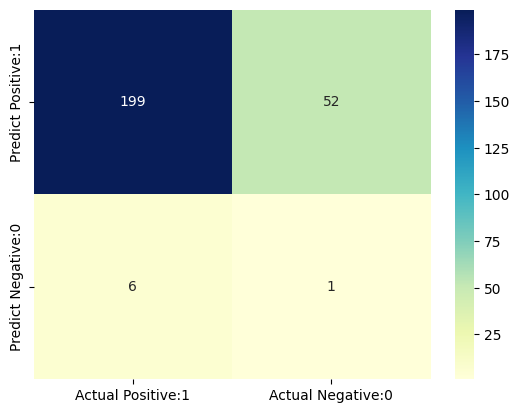

In [135]:
# visualize confusion matrix with seaborn heatmap

import seaborn as sns

cm_matrix = pd.DataFrame(data=cm, columns=['Actual Positive:1', 'Actual Negative:0'], 
                                 index=['Predict Positive:1', 'Predict Negative:0'])

sns.heatmap(cm_matrix, annot=True, fmt='d', cmap='YlGnBu')

**Classification metrices**

In [136]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.79      0.87       251
           1       0.02      0.14      0.03         7

    accuracy                           0.78       258
   macro avg       0.49      0.47      0.45       258
weighted avg       0.94      0.78      0.85       258



In [137]:
TP = cm[0,0]
TN = cm[1,1]
FP = cm[0,1]
FN = cm[1,0]

In [138]:
# print classification accuracy

classification_accuracy = (TP + TN) / float(TP + TN + FP + FN)

print('Classification accuracy : {0:0.4f}'.format(classification_accuracy))

Classification accuracy : 0.7752


In [139]:
# print classification error

classification_error = (FP + FN) / float(TP + TN + FP + FN)

print('Classification error : {0:0.4f}'.format(classification_error))

Classification error : 0.2248


**Precision**

Precision can be defined as the percentage of correctly predicted positive outcomes out of all the predicted positive outcomes. It can be given as the ratio of true positives (TP) to the sum of true and false positives (TP + FP).

So, Precision identifies the proportion of correctly predicted positive outcome. It is more concerned with the positive class than the negative class.

Mathematically, precision can be defined as the ratio of TP to (TP + FP).

In [140]:
# print precision score

precision = TP / float(TP + FP)


print('Precision : {0:0.4f}'.format(precision))

Precision : 0.7928


**Recall**

Recall can be defined as the percentage of correctly predicted positive outcomes out of all the actual positive outcomes. It can be given as the ratio of true positives (TP) to the sum of true positives and false negatives (TP + FN). Recall is also called Sensitivity.

Recall identifies the proportion of correctly predicted actual positives.

Mathematically, recall can be given as the ratio of TP to (TP + FN).

In [141]:
recall = TP / float(TP + FN)

print('Recall or Sensitivity : {0:0.4f}'.format(recall))

false_positive_rate = FP / float(FP + TN)


print('False Positive Rate : {0:0.4f}'.format(false_positive_rate))

specificity = TN / (TN + FP)

print('Specificity : {0:0.4f}'.format(specificity))

# print classification accuracy

classification_accuracy = (TP + TN) / float(TP + TN + FP + FN)

print('Classification accuracy : {0:0.4f}'.format(classification_accuracy))

# print precision score

precision = TP / float(TP + FP)


print('Precision : {0:0.4f}'.format(precision))

#Training set score: 0.8117
#Test set score: 0.7752

Recall or Sensitivity : 0.9707
False Positive Rate : 0.9811
Specificity : 0.0189
Classification accuracy : 0.7752
Precision : 0.7928


In [142]:

#True Positive Rate is synonymous with Recall

true_positive_rate = TP / float(TP + FN)


print('True Positive Rate : {0:0.4f}'.format(true_positive_rate))

True Positive Rate : 0.9707


**f1-score**

f1-score is the weighted harmonic mean of precision and recall. The best possible f1-score would be 1.0 and the worst would be 0.0. f1-score is the harmonic mean of precision and recall. So, f1-score is always lower than accuracy measures as they embed precision and recall into their computation. The weighted average of f1-score should be used to compare classifier models, not global accuracy.

Support
Support is the actual number of occurrences of the class in our dataset.



In [143]:
# print the first 10 predicted probabilities of two classes- 0 and 1

y_pred_prob = gnb.predict_proba(X_test)[0:10]

y_pred_prob

array([[0., 1.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [1., 0.]])

**ROC - AUC**

Another tool to measure the classification model performance visually is ROC Curve. ROC Curve stands for Receiver Operating Characteristic Curve. An ROC Curve is a plot which shows the performance of a classification model at various classification threshold levels.

The ROC Curve plots the True Positive Rate (TPR) against the False Positive Rate (FPR) at various threshold levels.

True Positive Rate (TPR) is also called Recall. It is defined as the ratio of TP to (TP + FN).

False Positive Rate (FPR) is defined as the ratio of FP to (FP + TN).

In the ROC Curve, we will focus on the TPR (True Positive Rate) and FPR (False Positive Rate) of a single point. This will give us the general performance of the ROC curve which consists of the TPR and FPR at various threshold levels. So, an ROC Curve plots TPR vs FPR at different classification threshold levels. If we lower the threshold levels, it may result in more items being classified as positve. It will increase both True Positives (TP) and False Positives (FP).

ROC AUC
ROC AUC stands for Receiver Operating Characteristic - Area Under Curve. It is a technique to compare classifier performance. In this technique, we measure the area under the curve (AUC). A perfect classifier will have a ROC AUC equal to 1, whereas a purely random classifier will have a ROC AUC equal to 0.5.

So, ROC AUC is the percentage of the ROC plot that is underneath the curve.

In [144]:
# compute ROC AUC

from sklearn.metrics import roc_auc_score

y_pred1 = gnb.predict_proba(X_test)[:, 1]

ROC_AUC = roc_auc_score(y_test, y_pred1)

print('ROC AUC : {:.4f}'.format(ROC_AUC))

ROC AUC : 0.4678


In [145]:
# calculate cross-validated ROC AUC 

from sklearn.model_selection import cross_val_score

Cross_validated_ROC_AUC = cross_val_score(gnb, X_train, y_train, cv=5, scoring='roc_auc').mean()

print('Cross validated ROC AUC : {:.4f}'.format(Cross_validated_ROC_AUC))

Cross validated ROC AUC : 0.6094


**k-Fold Cross Validation**

In [146]:
# Applying 10-Fold Cross Validation

from sklearn.model_selection import cross_val_score

scores = cross_val_score(gnb, X_train, y_train, cv = 10, scoring='accuracy')

print('Cross-validation scores:{}'.format(scores))

Cross-validation scores:[0.81666667 0.73333333 0.9        0.76666667 0.81666667 0.98333333
 0.8        0.75       0.85       0.75      ]


In [147]:
# compute Average cross-validation score

print('Average cross-validation score: {:.4f}'.format(scores.mean()))

Average cross-validation score: 0.8167


**Results and conclusion**

1. I used a Kaggle workbook [https://www.kaggle.com/code/prashant111/naive-bayes-classifier-in-python] to guide me through the process of implementing Naive Bayes classifier. 
2. I used the risk factors for cervical cancer dataset from UC Irvine MLR [https://archive.ics.uci.edu/dataset/383/cervical+cancer+risk+factors]
3. My model has high recall (catches actual cancer cases) but has very low specificity (too many false positives)
4. Future thoughts: I need to handle the imbalance in my data - there are too many false positives. 